<a href="https://colab.research.google.com/github/Dawood-Ali123/Pytorch_learning/blob/main/BreastCancerprediction_using_NN_Module.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [127]:
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

In [128]:
import kagglehub
path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")

Using Colab cache for faster access to the 'breast-cancer-wisconsin-data' dataset.


In [129]:
print(path)

/kaggle/input/breast-cancer-wisconsin-data


In [130]:
import pandas as pd

df = pd.read_csv(path + "/data.csv")
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [131]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [132]:
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [133]:
df.drop('id', axis=1, inplace=True)
df.drop('Unnamed: 32', axis=1, inplace=True)

In [134]:
import seaborn as sns
import matplotlib.pyplot as plt

In [135]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

In [136]:
df.shape

(569, 31)

In [137]:
numerical_cols=df.select_dtypes(include=['int64','float64']).columns
numerical_cols

Index(['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
       'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

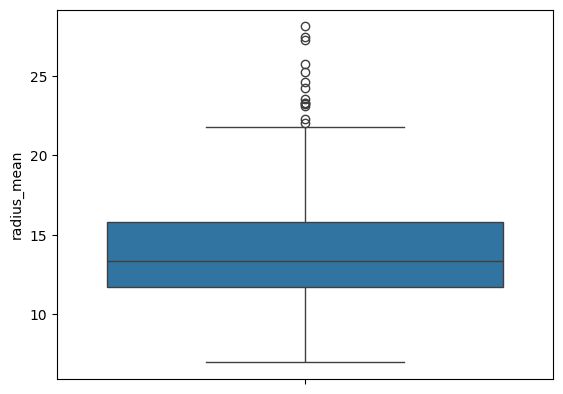

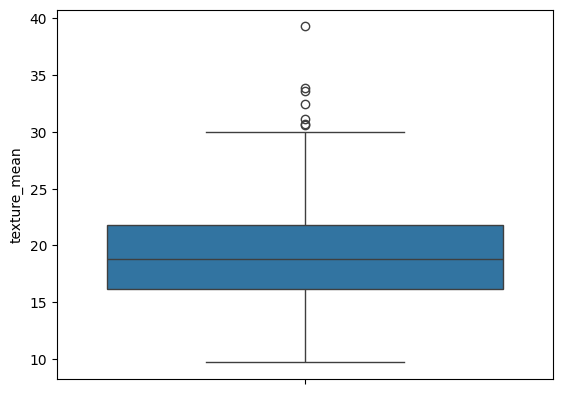

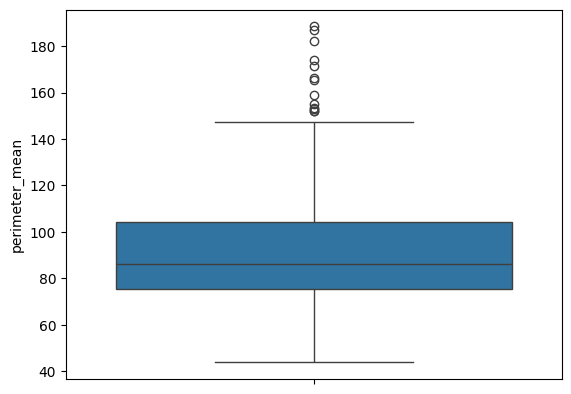

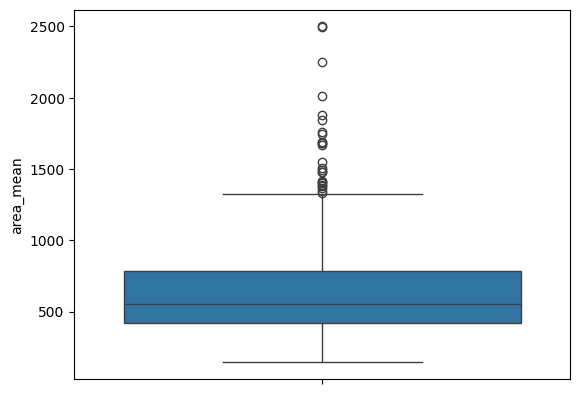

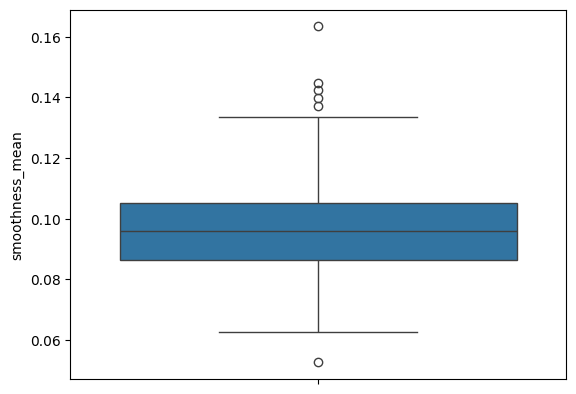

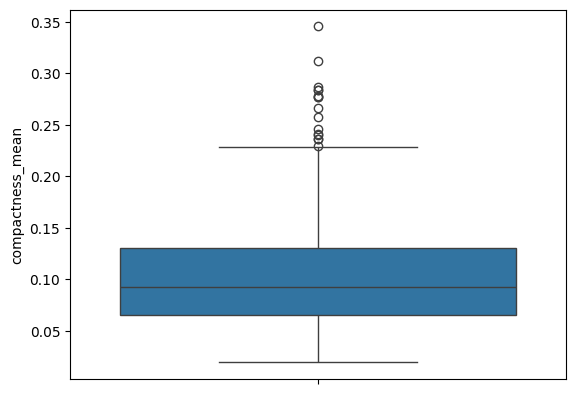

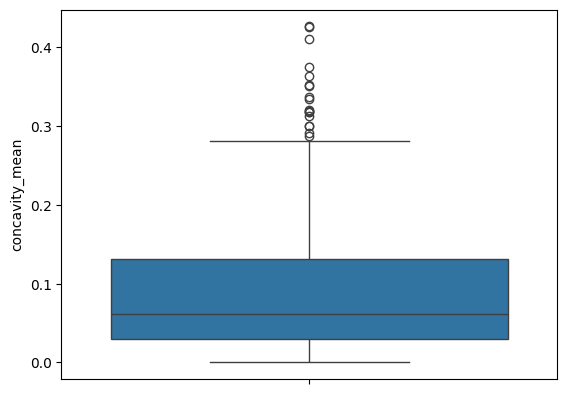

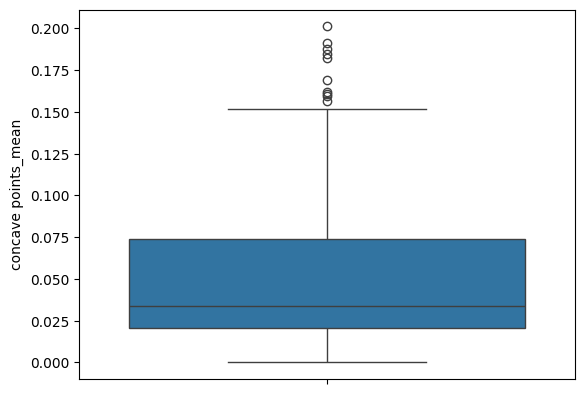

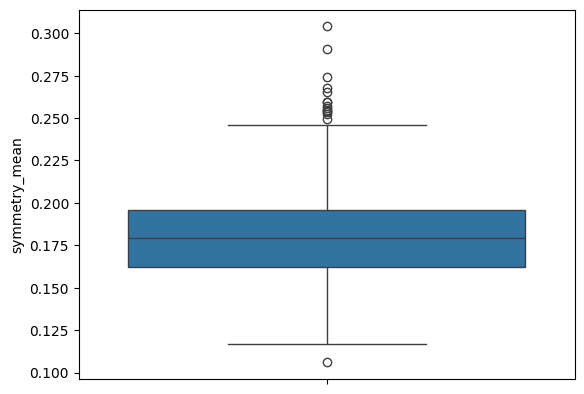

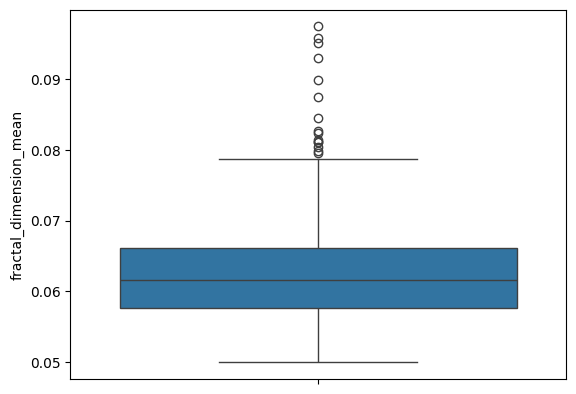

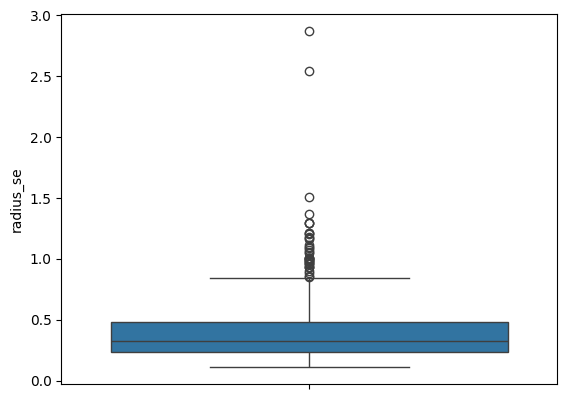

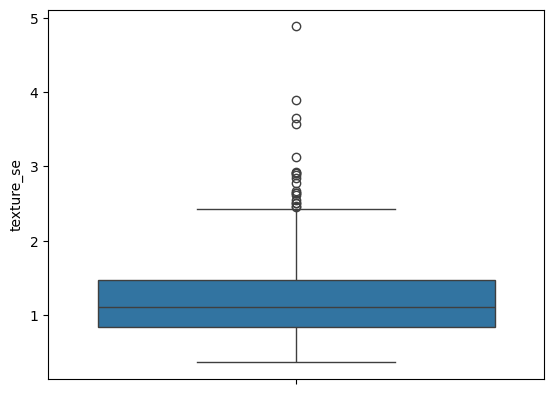

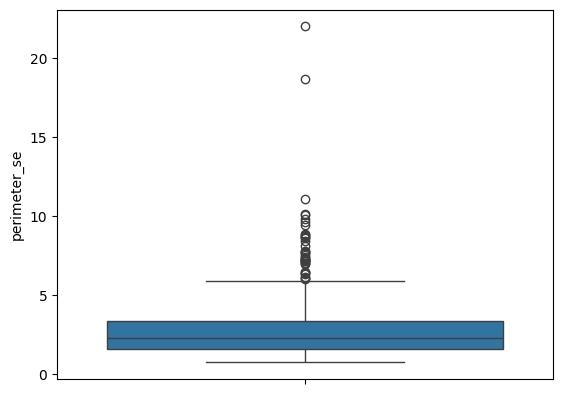

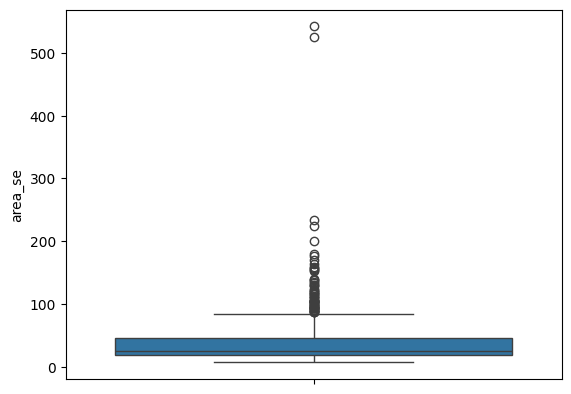

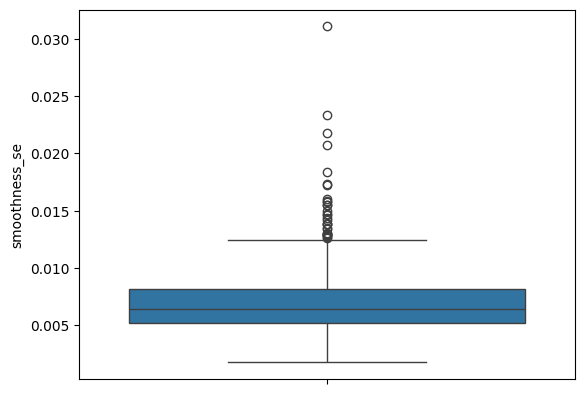

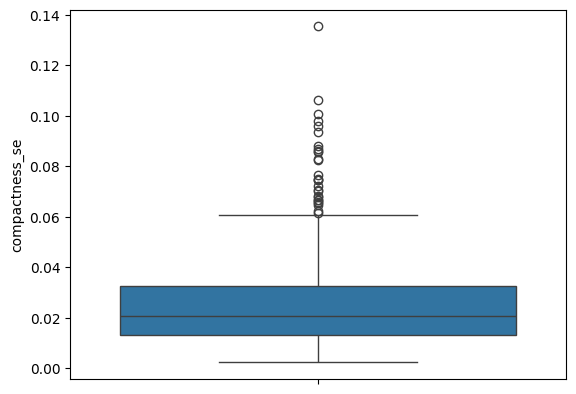

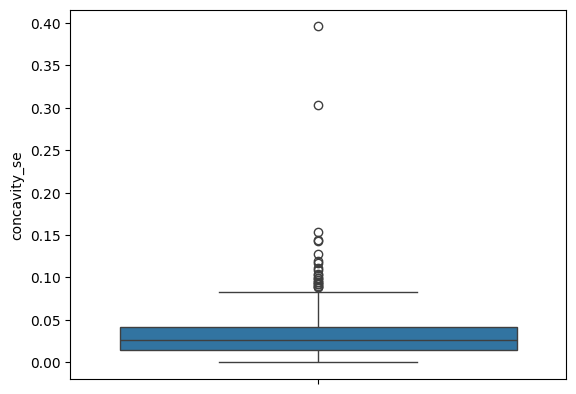

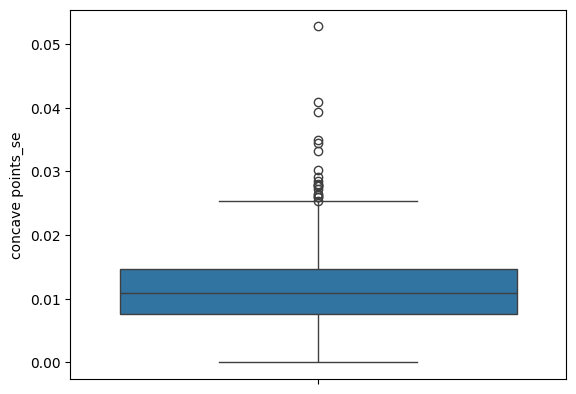

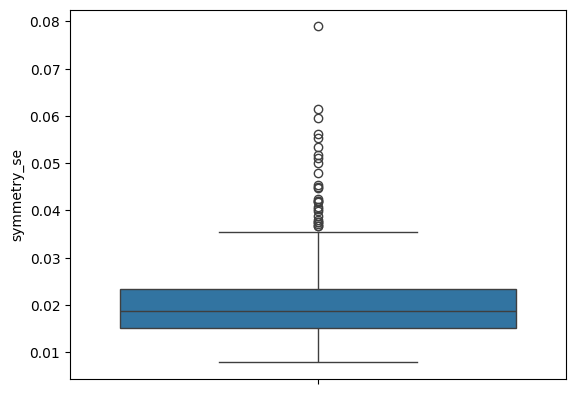

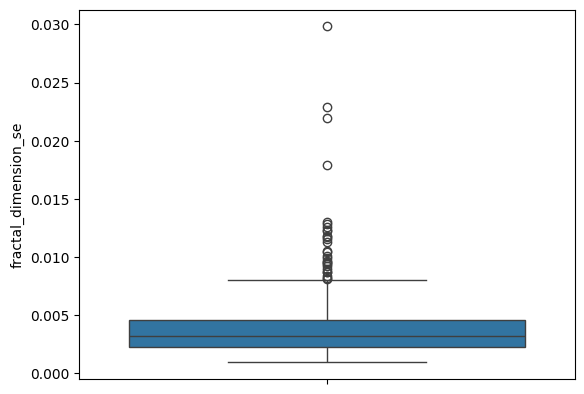

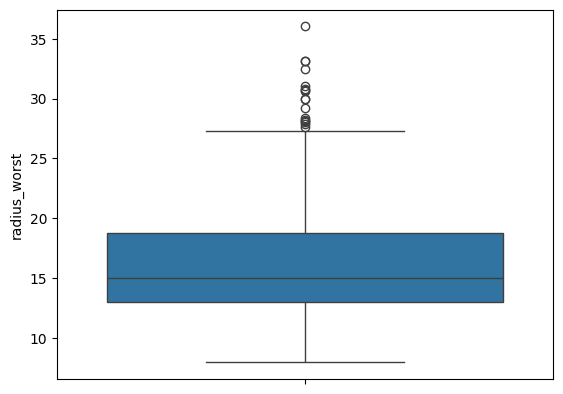

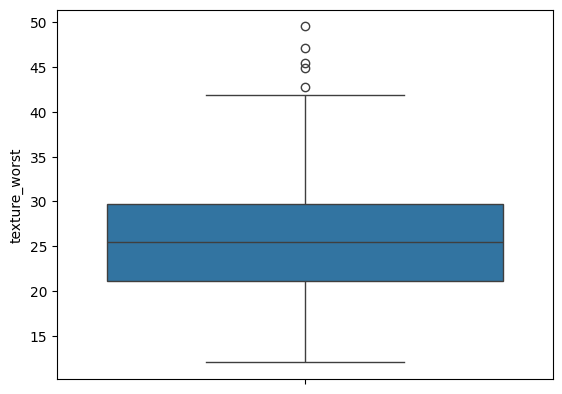

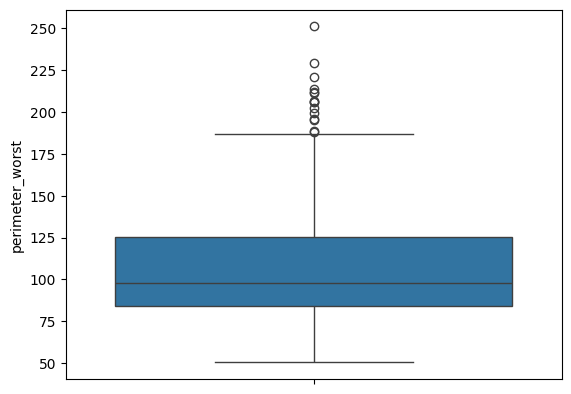

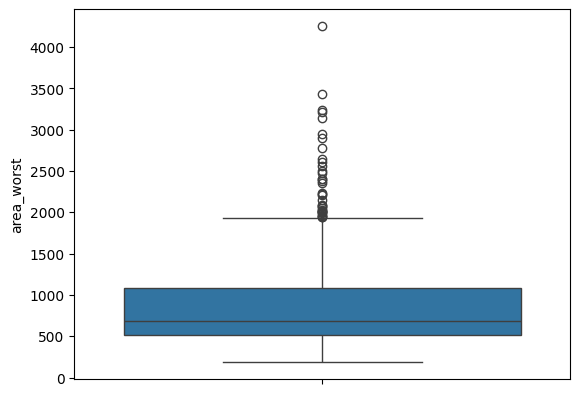

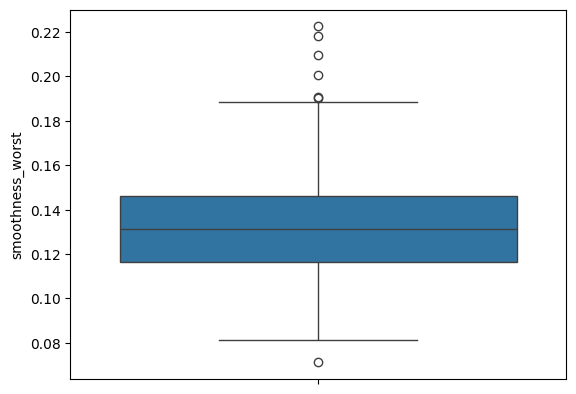

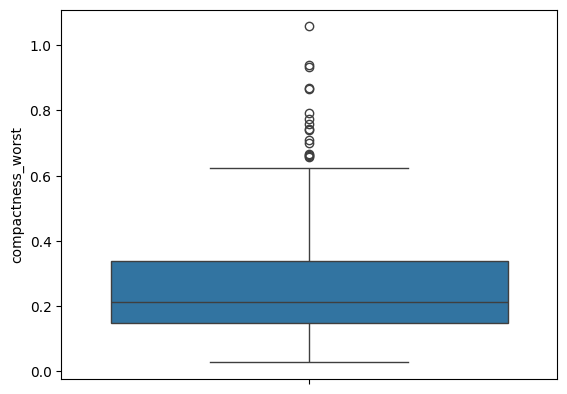

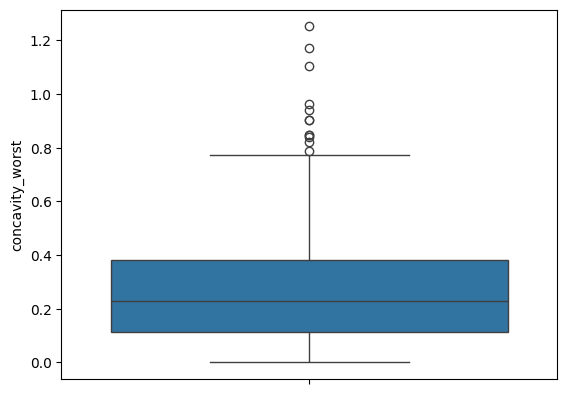

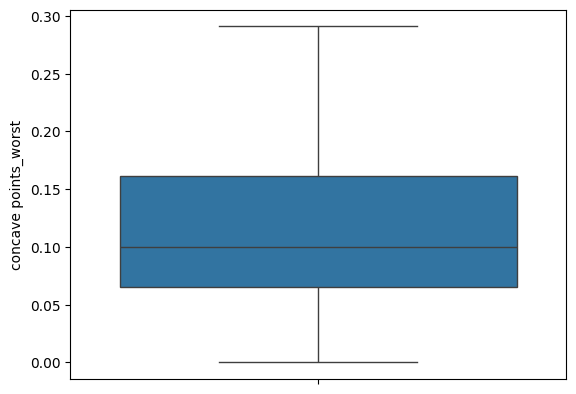

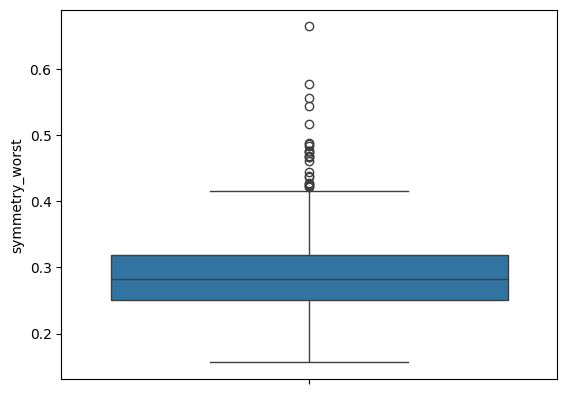

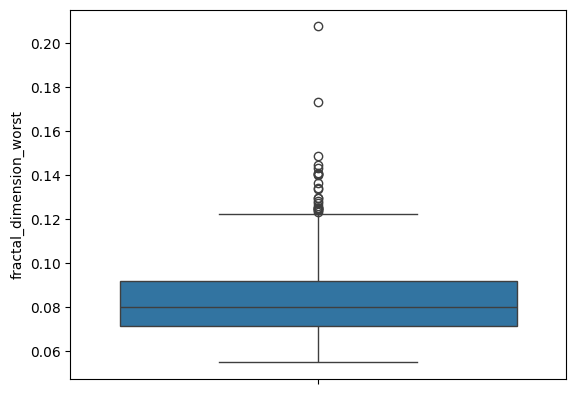

In [138]:
for col in numerical_cols:
    sns.boxplot(df[col])
    plt.show()

radius_mean Skewnness 0.9423795716730992


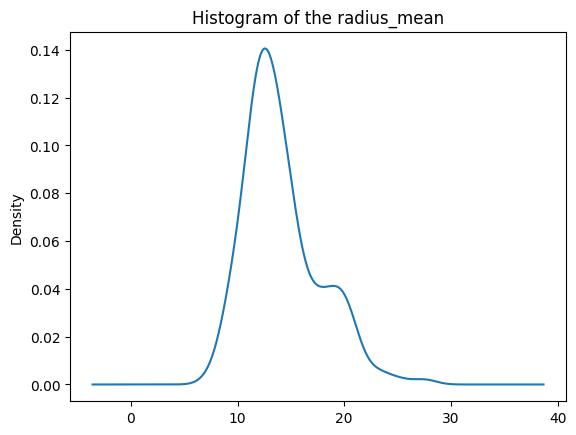

texture_mean Skewnness 0.6504495420828159


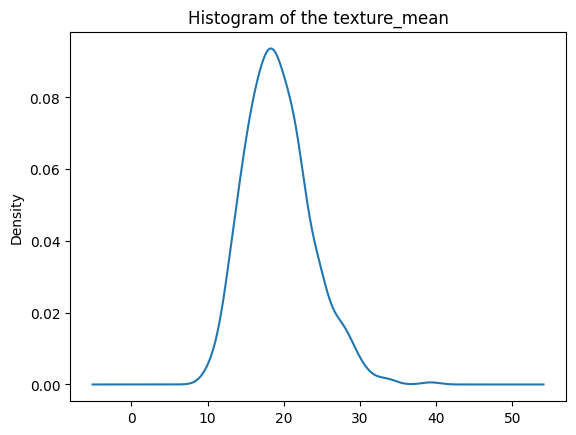

perimeter_mean Skewnness 0.9906504253930081


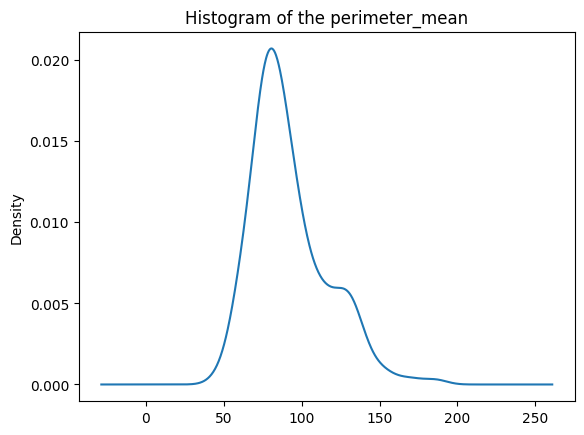

area_mean Skewnness 1.6457321756240424


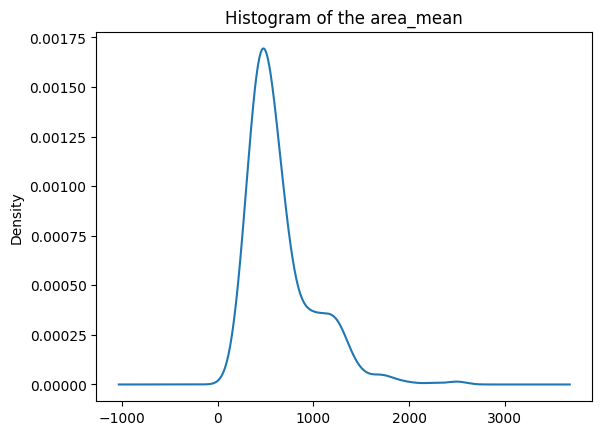

smoothness_mean Skewnness 0.45632376481955844


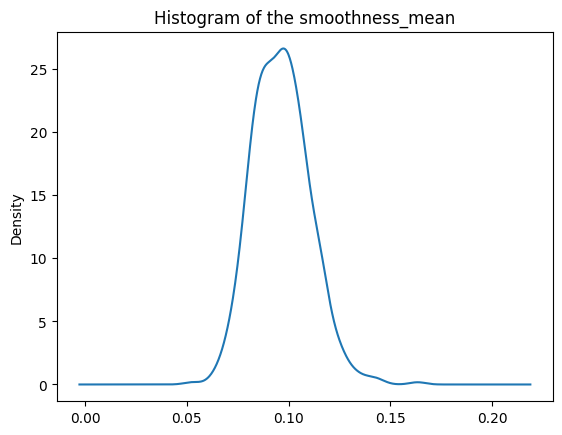

compactness_mean Skewnness 1.1901230311980404


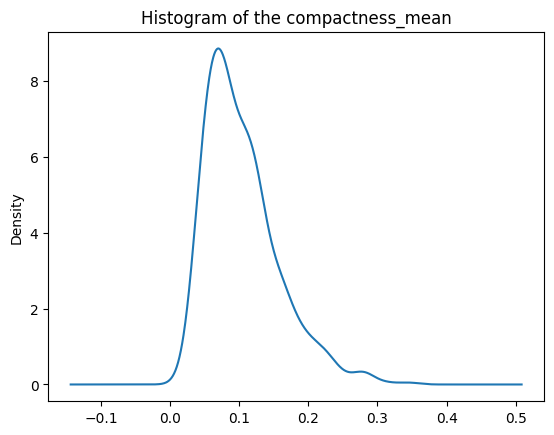

concavity_mean Skewnness 1.4011797389486722


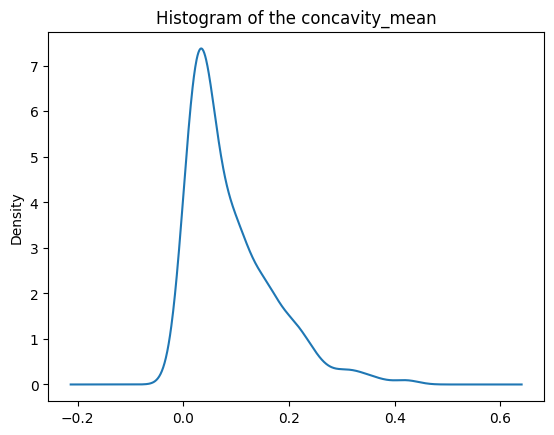

concave points_mean Skewnness 1.1711800812336282


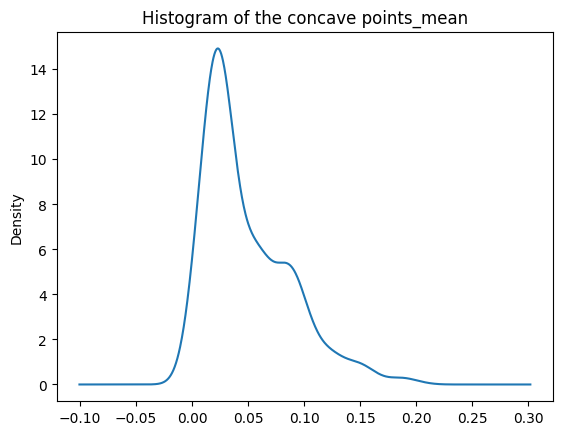

symmetry_mean Skewnness 0.7256089733641999


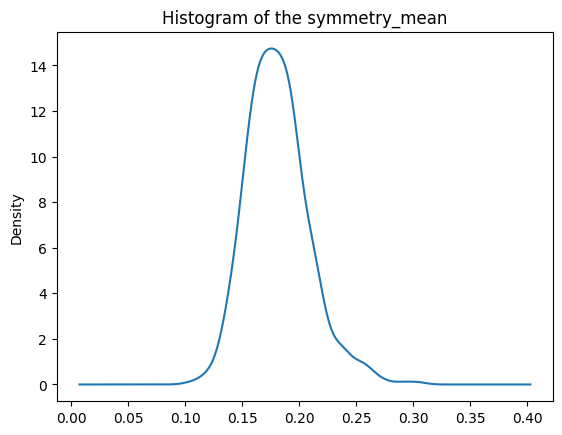

fractal_dimension_mean Skewnness 1.3044888125755076


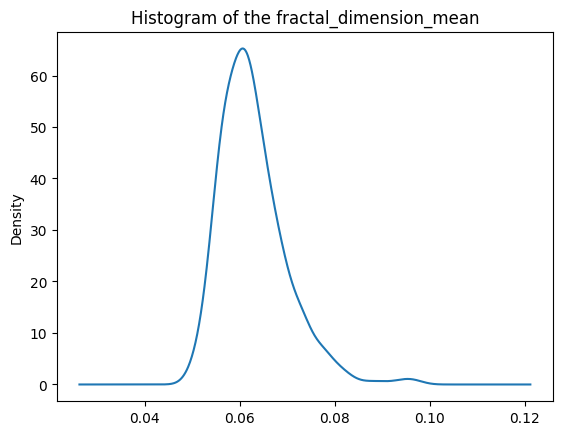

radius_se Skewnness 3.0886121663847574


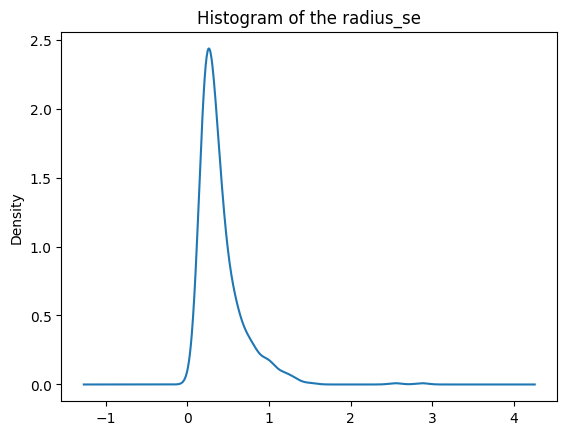

texture_se Skewnness 1.646443808753053


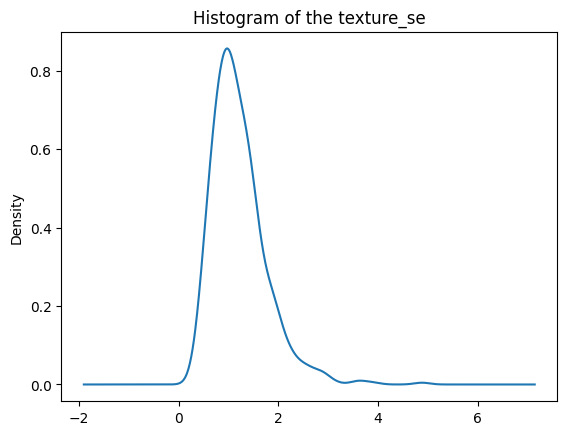

perimeter_se Skewnness 3.443615202194899


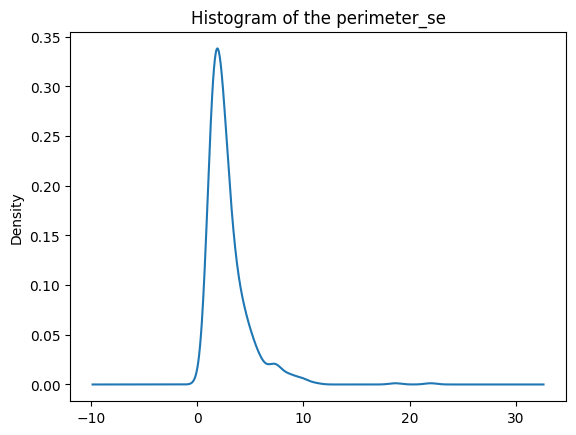

area_se Skewnness 5.447186284898394


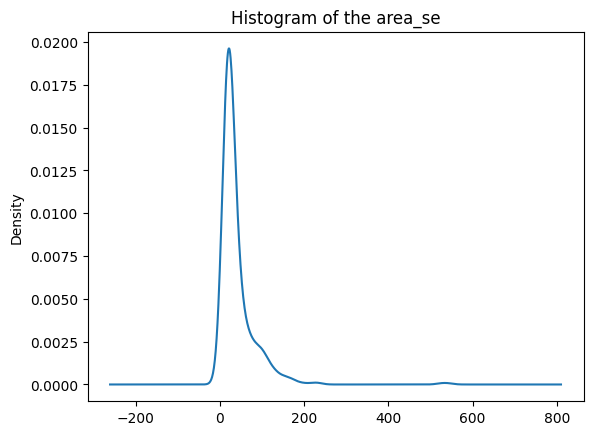

smoothness_se Skewnness 2.314450056636759


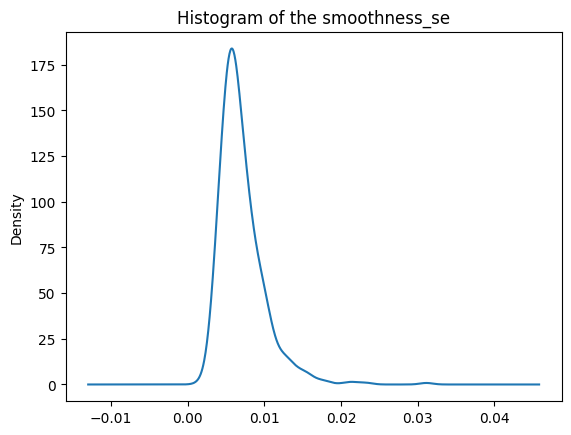

compactness_se Skewnness 1.9022207096378565


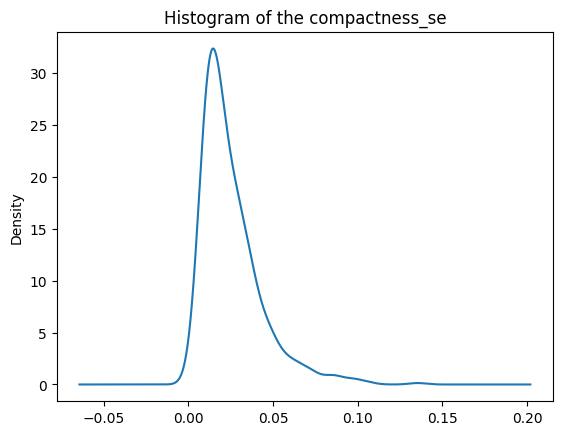

concavity_se Skewnness 5.110463049043661


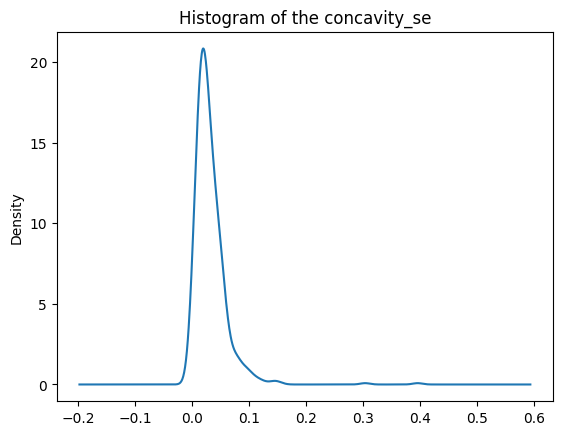

concave points_se Skewnness 1.4446781446974786


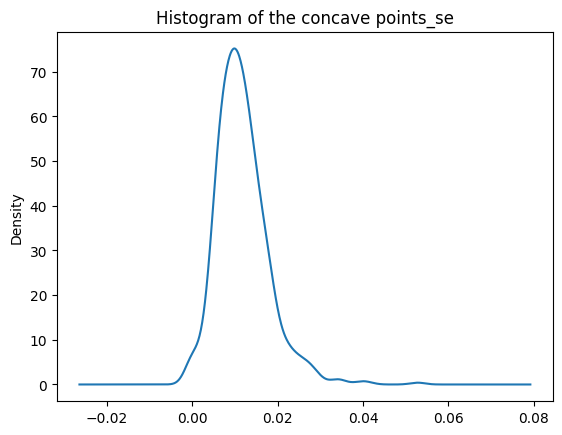

symmetry_se Skewnness 2.1951328995478216


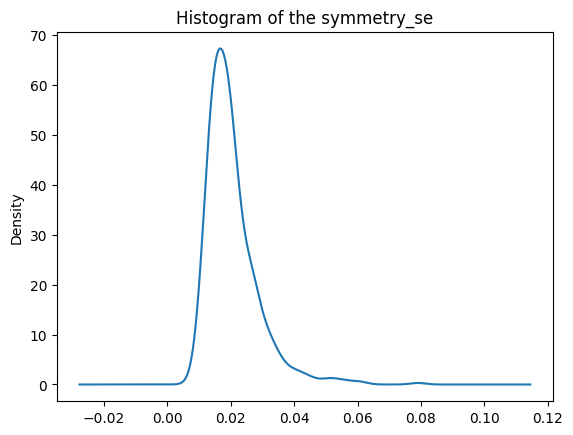

fractal_dimension_se Skewnness 3.923968620227413


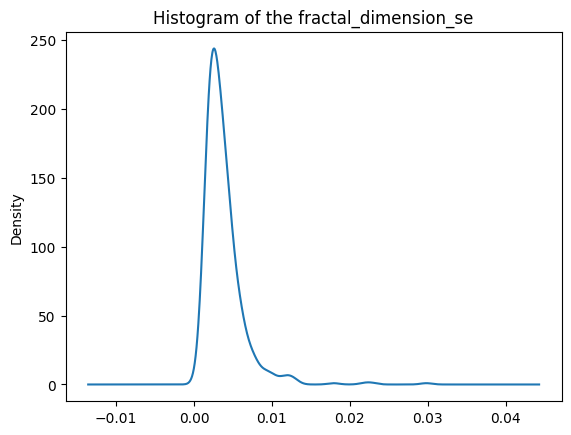

radius_worst Skewnness 1.1031152059604372


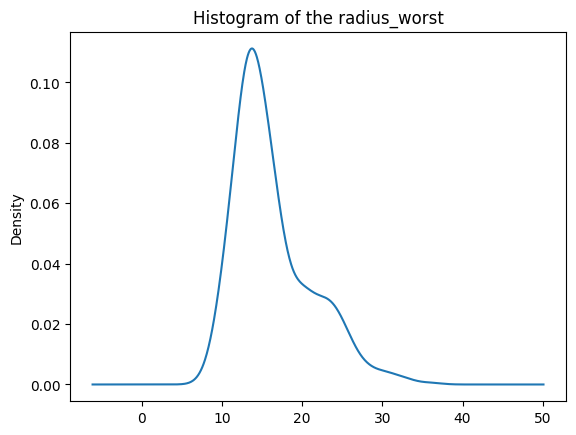

texture_worst Skewnness 0.49832130948716474


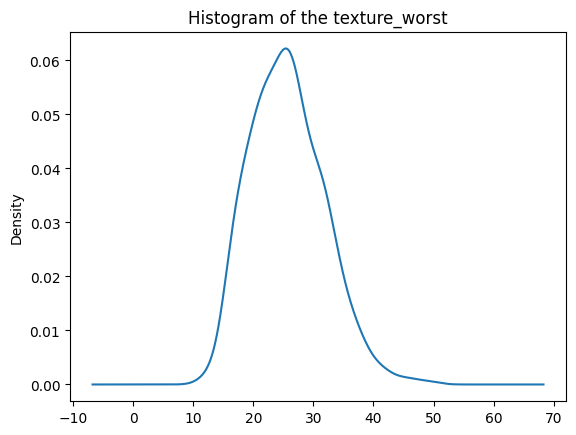

perimeter_worst Skewnness 1.1281638713683722


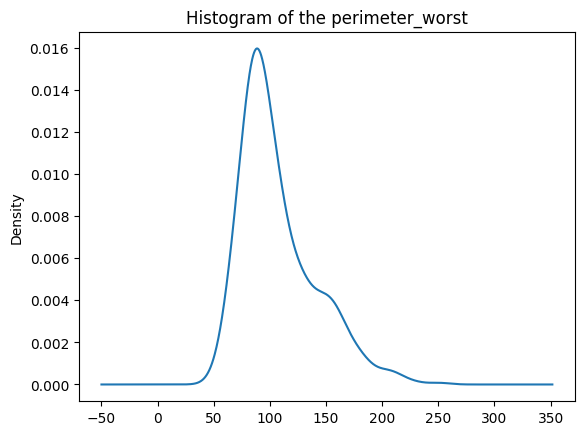

area_worst Skewnness 1.8593732724433467


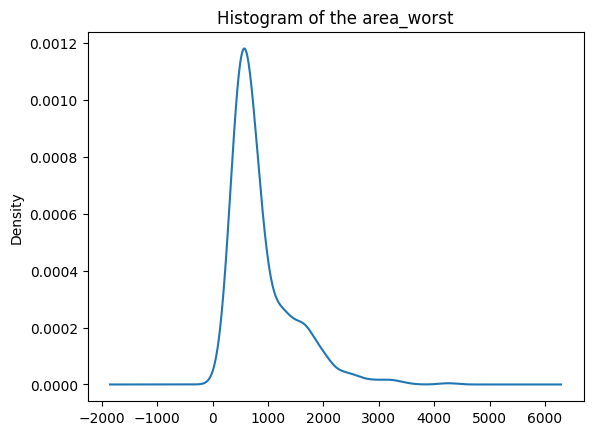

smoothness_worst Skewnness 0.4154259962824678


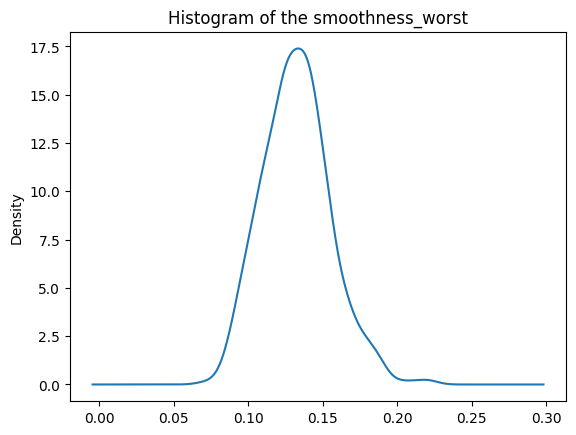

compactness_worst Skewnness 1.4735549003297956


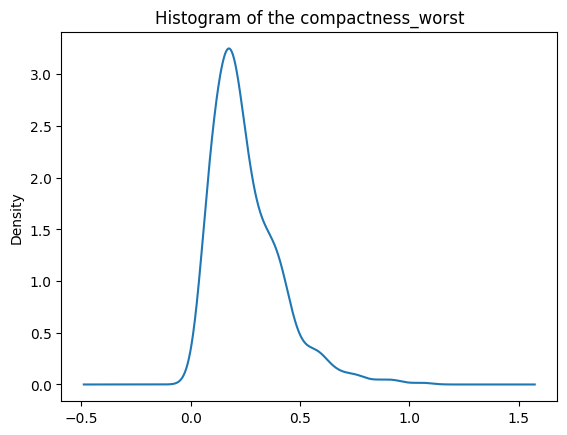

concavity_worst Skewnness 1.1502368219460262


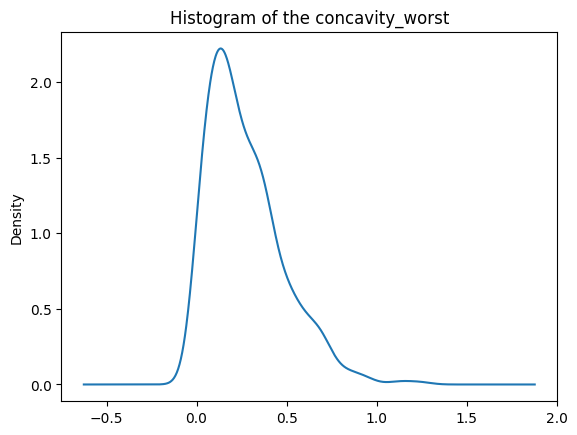

concave points_worst Skewnness 0.49261552688550875


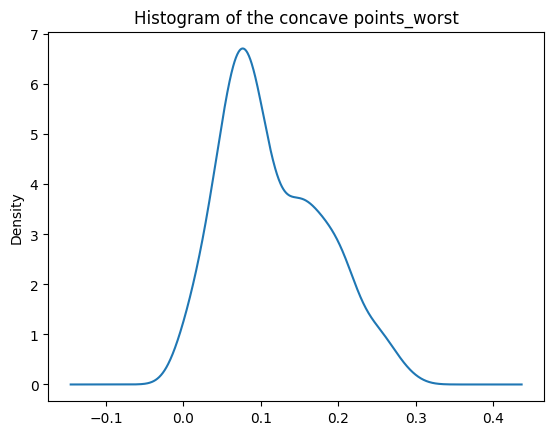

symmetry_worst Skewnness 1.433927765189328


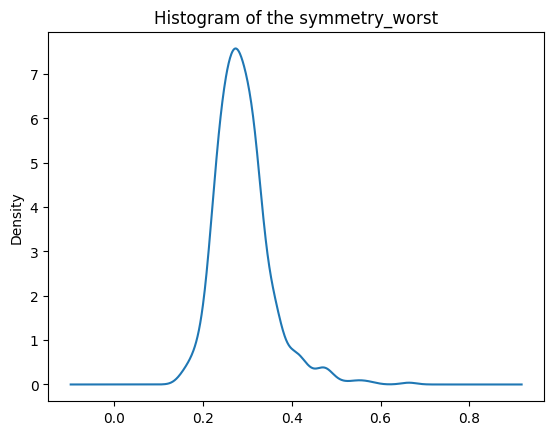

fractal_dimension_worst Skewnness 1.6625792663955146


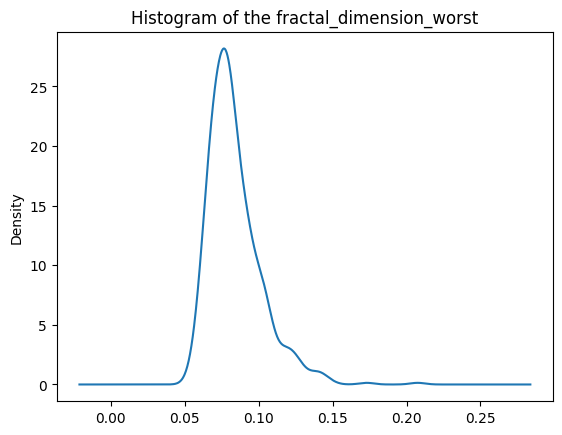

In [139]:
for col in numerical_cols:
  print(col,"Skewnness",df[col].skew())
  df[col].plot(kind='kde')
  plt.title(f"Histogram of the {col}")
  plt.show()

In [140]:
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [141]:
X_train

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
68,9.029,17.33,58.79,250.5,0.10660,0.14130,0.31300,0.04375,0.2111,0.08046,...,10.310,22.65,65.50,324.7,0.14820,0.43650,1.25200,0.17500,0.4228,0.11750
181,21.090,26.57,142.70,1311.0,0.11410,0.28320,0.24870,0.14960,0.2395,0.07398,...,26.680,33.48,176.50,2089.0,0.14910,0.75840,0.67800,0.29030,0.4098,0.12840
63,9.173,13.86,59.20,260.9,0.07721,0.08751,0.05988,0.02180,0.2341,0.06963,...,10.010,19.23,65.59,310.1,0.09836,0.16780,0.13970,0.05087,0.3282,0.08490
248,10.650,25.22,68.01,347.0,0.09657,0.07234,0.02379,0.01615,0.1897,0.06329,...,12.250,35.19,77.98,455.7,0.14990,0.13980,0.11250,0.06136,0.3409,0.08147
60,10.170,14.88,64.55,311.9,0.11340,0.08061,0.01084,0.01290,0.2743,0.06960,...,11.020,17.45,69.86,368.6,0.12750,0.09866,0.02168,0.02579,0.3557,0.08020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,8.888,14.64,58.79,244.0,0.09783,0.15310,0.08606,0.02872,0.1902,0.08980,...,9.733,15.67,62.56,284.4,0.12070,0.24360,0.14340,0.04786,0.2254,0.10840
106,11.640,18.33,75.17,412.5,0.11420,0.10170,0.07070,0.03485,0.1801,0.06520,...,13.140,29.26,85.51,521.7,0.16880,0.26600,0.28730,0.12180,0.2806,0.09097
270,14.290,16.82,90.30,632.6,0.06429,0.02675,0.00725,0.00625,0.1508,0.05376,...,14.910,20.65,94.44,684.6,0.08567,0.05036,0.03866,0.03333,0.2458,0.06120
435,13.980,19.62,91.12,599.5,0.10600,0.11330,0.11260,0.06463,0.1669,0.06544,...,17.040,30.80,113.90,869.3,0.16130,0.35680,0.40690,0.18270,0.3179,0.10550


In [142]:
Y_train

,diagnosis
68,B
181,M
63,B
248,B
60,B
...,...
71,B
106,B
270,B
435,M


In [143]:
encoder=LabelEncoder()
Y_train_encoded = encoder.fit_transform(Y_train)
Y_test_encoded = encoder.transform(Y_test)

In [144]:
X_train_cols=df.select_dtypes(include=['int64','float64']).columns
X_train_cols

Index(['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
       'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

radius_mean Skewnness 0.9423795716730992


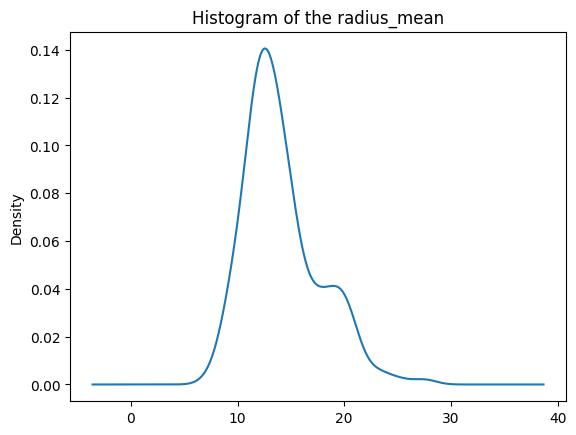

texture_mean Skewnness 0.6504495420828159


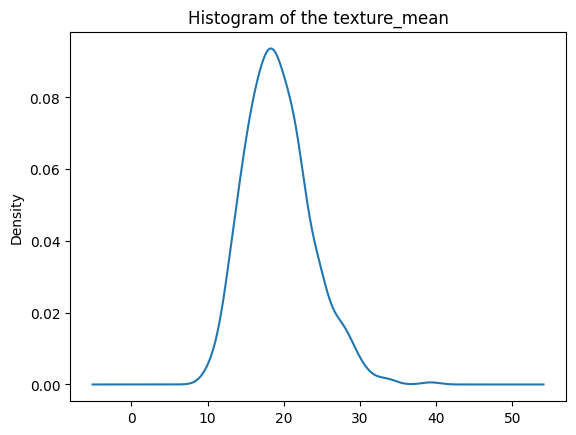

perimeter_mean Skewnness 0.9906504253930081


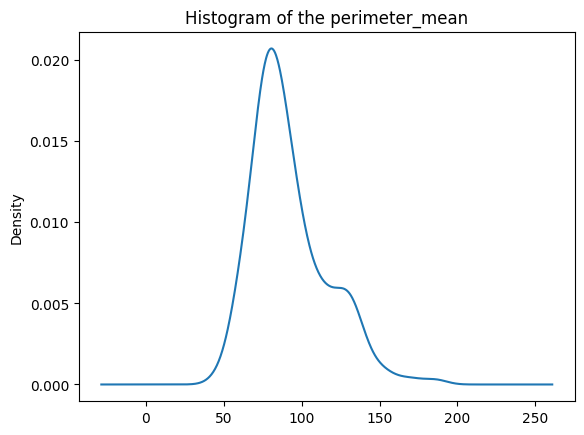

area_mean Skewnness 1.6457321756240424


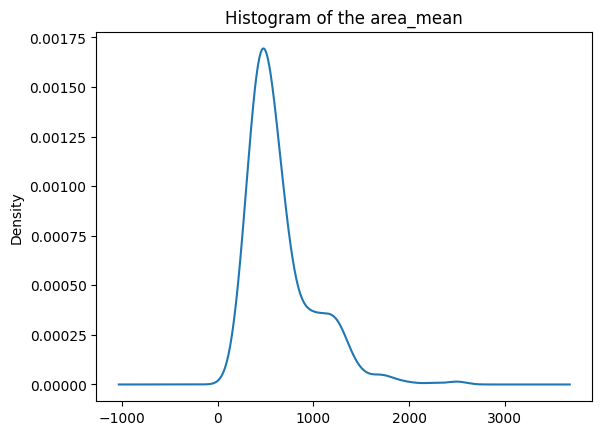

smoothness_mean Skewnness 0.45632376481955844


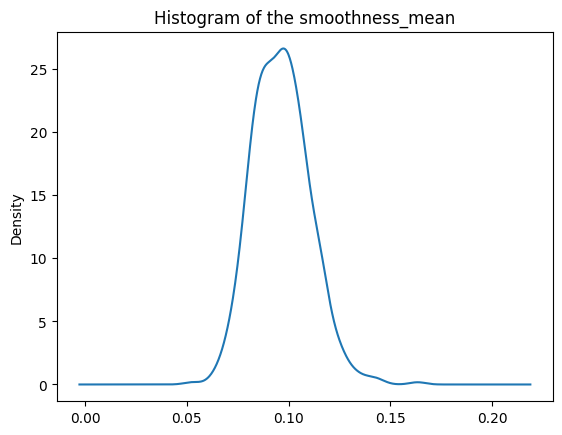

compactness_mean Skewnness 1.1901230311980404


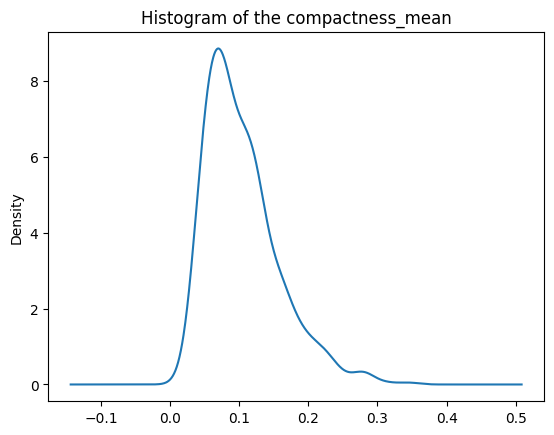

concavity_mean Skewnness 1.4011797389486722


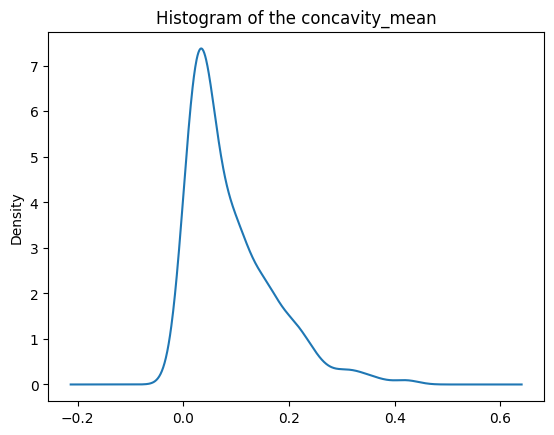

concave points_mean Skewnness 1.1711800812336282


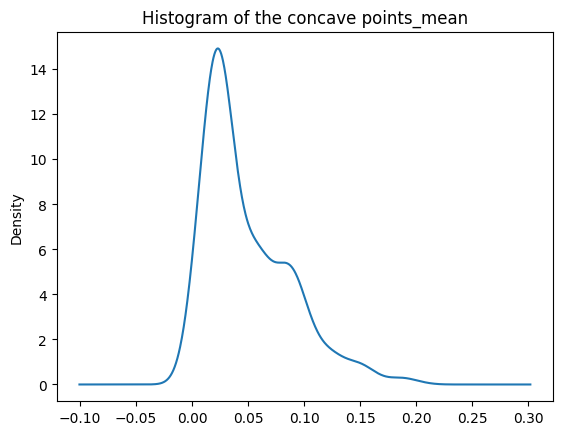

symmetry_mean Skewnness 0.7256089733641999


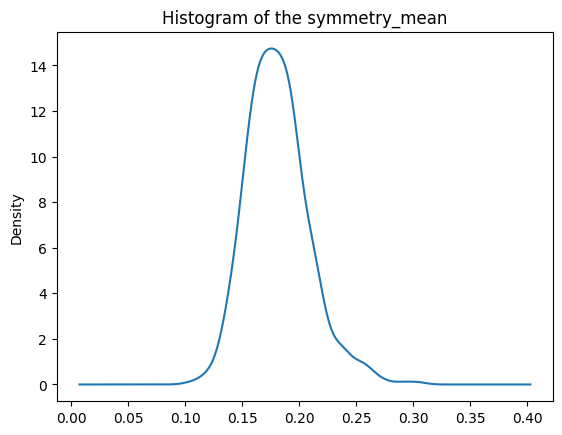

fractal_dimension_mean Skewnness 1.3044888125755076


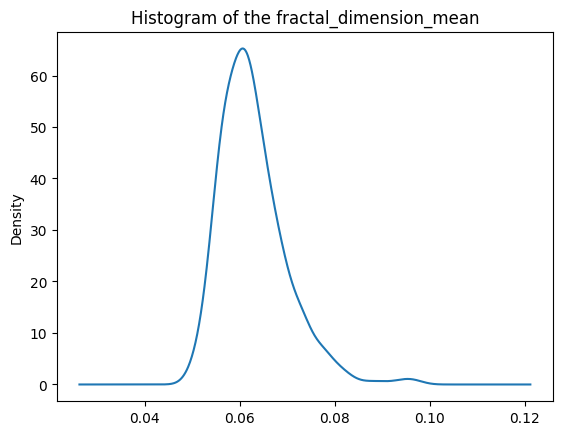

radius_se Skewnness 3.0886121663847574


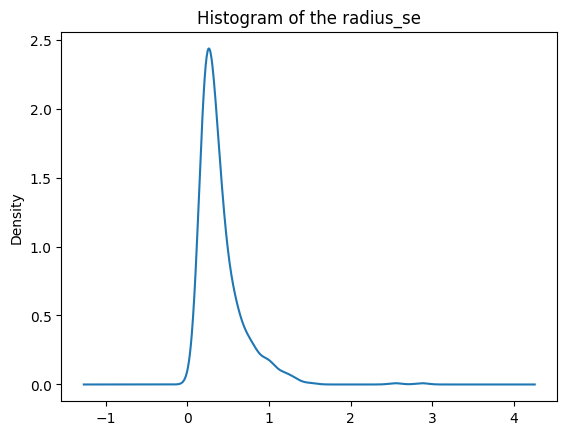

texture_se Skewnness 1.646443808753053


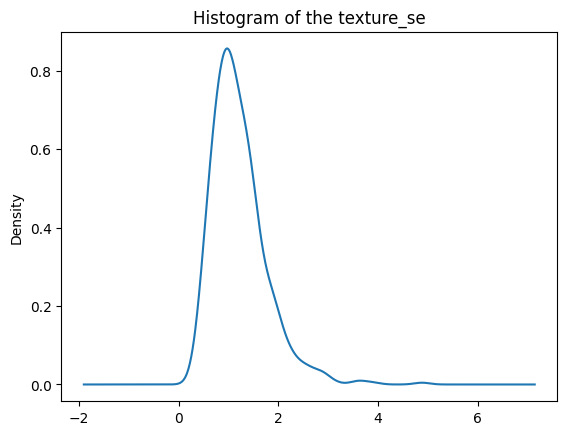

perimeter_se Skewnness 3.443615202194899


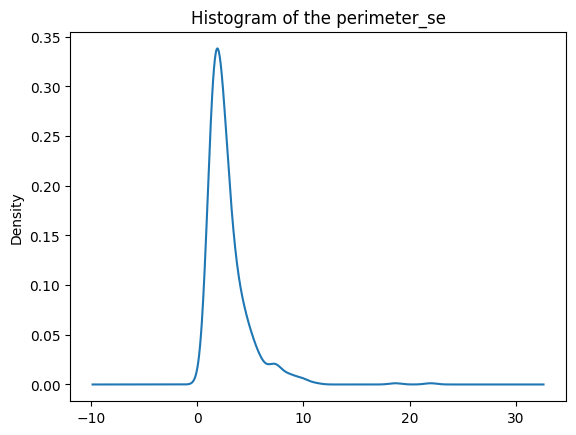

area_se Skewnness 5.447186284898394


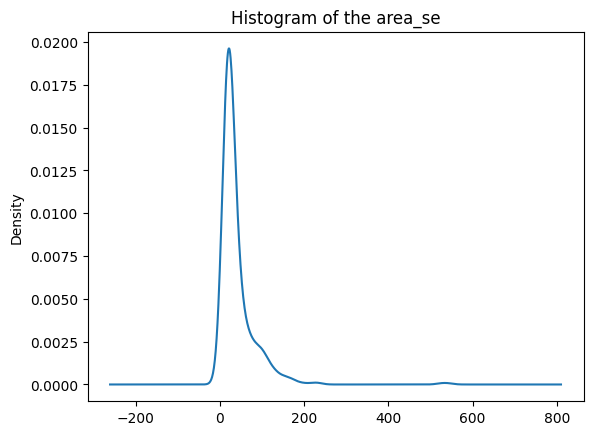

smoothness_se Skewnness 2.314450056636759


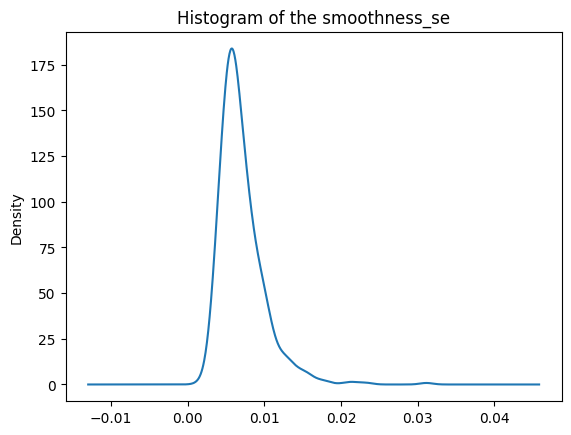

compactness_se Skewnness 1.9022207096378565


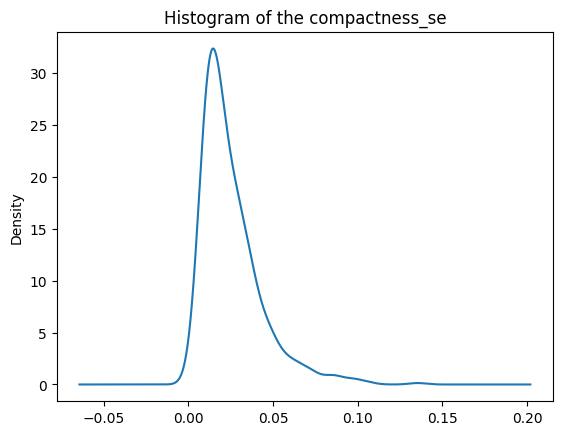

concavity_se Skewnness 5.110463049043661


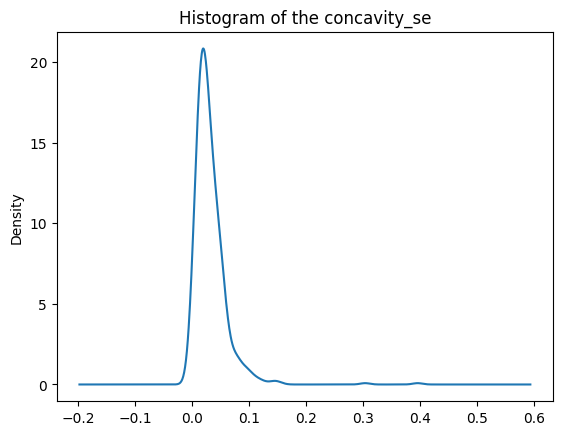

concave points_se Skewnness 1.4446781446974786


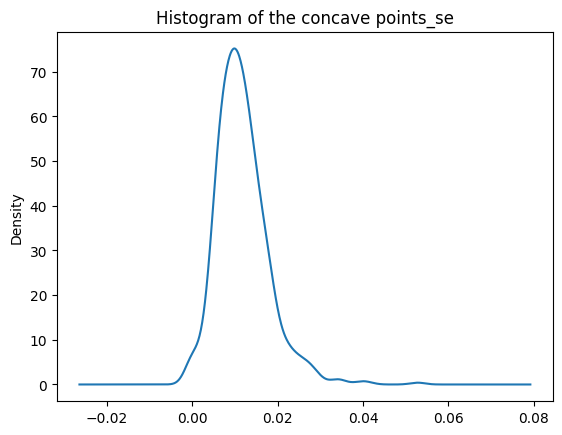

symmetry_se Skewnness 2.1951328995478216


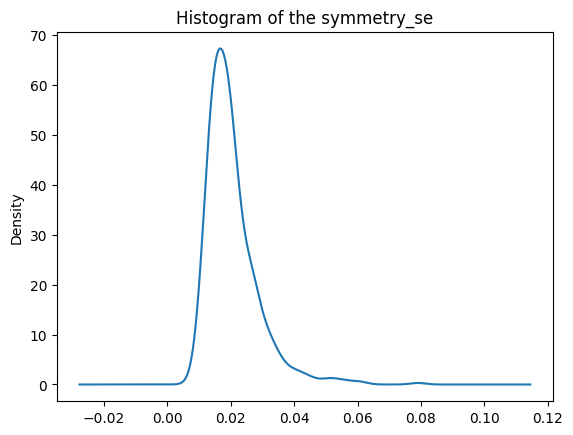

fractal_dimension_se Skewnness 3.923968620227413


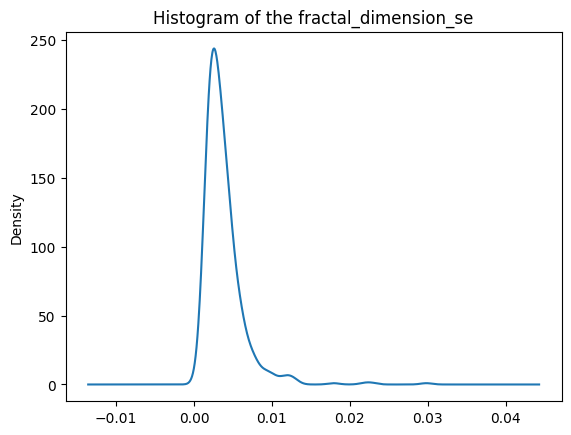

radius_worst Skewnness 1.1031152059604372


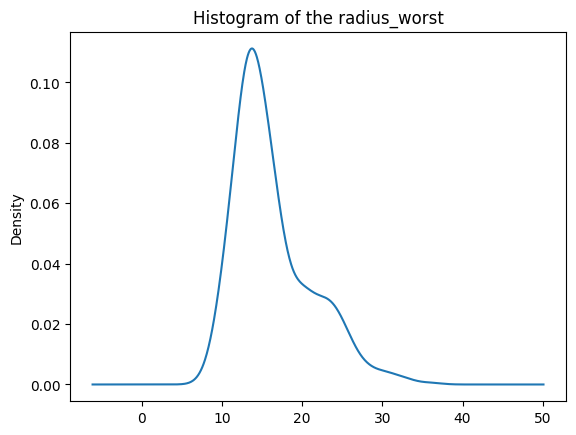

texture_worst Skewnness 0.49832130948716474


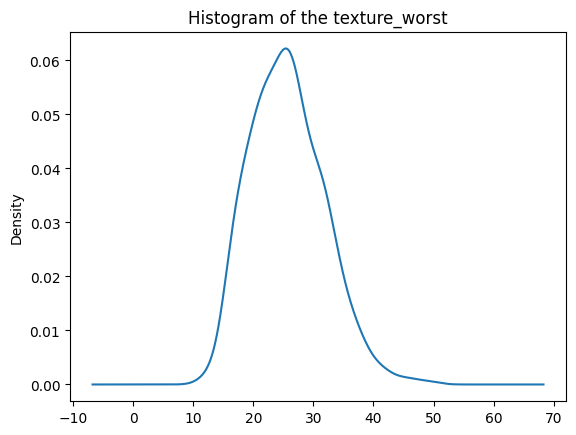

perimeter_worst Skewnness 1.1281638713683722


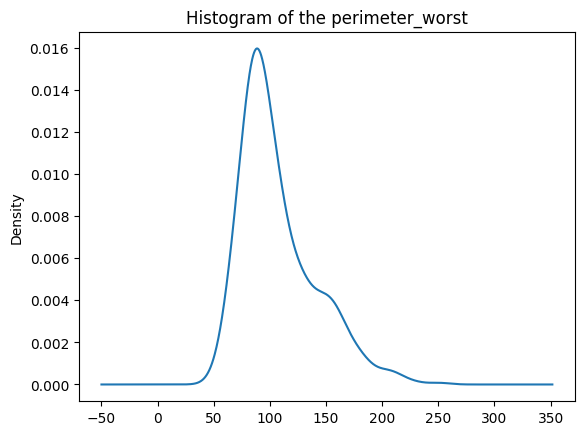

area_worst Skewnness 1.8593732724433467


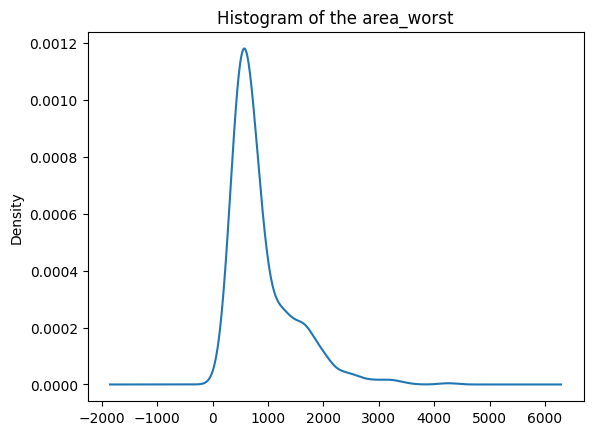

smoothness_worst Skewnness 0.4154259962824678


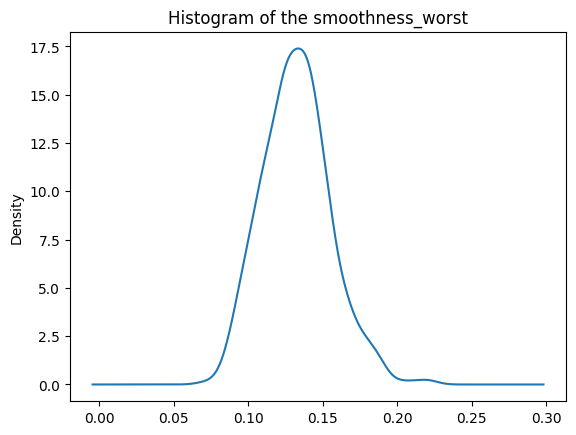

compactness_worst Skewnness 1.4735549003297956


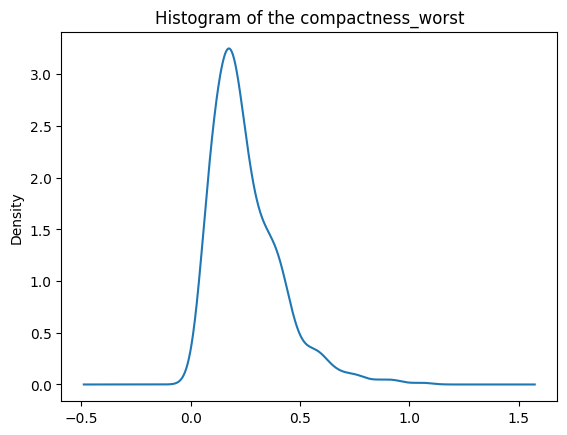

concavity_worst Skewnness 1.1502368219460262


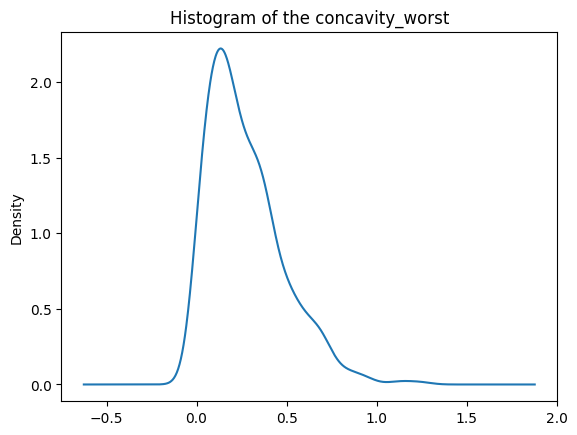

concave points_worst Skewnness 0.49261552688550875


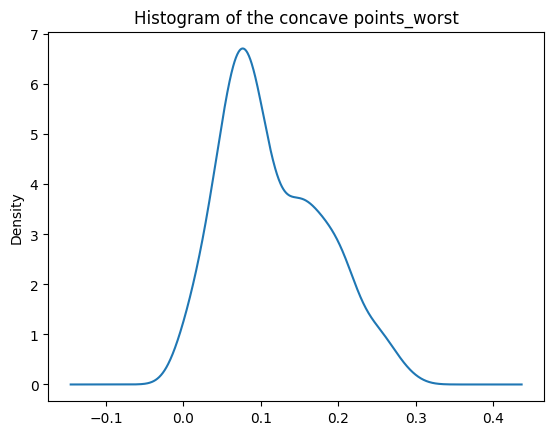

symmetry_worst Skewnness 1.433927765189328


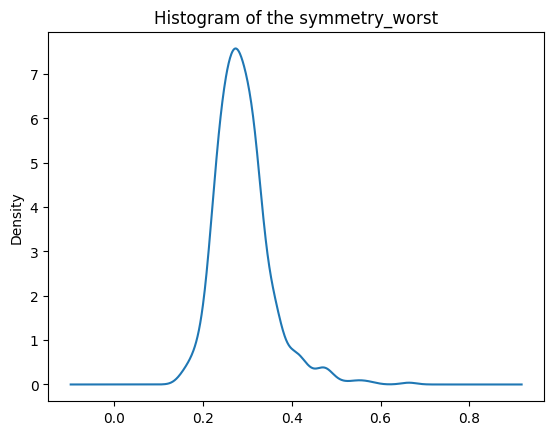

fractal_dimension_worst Skewnness 1.6625792663955146


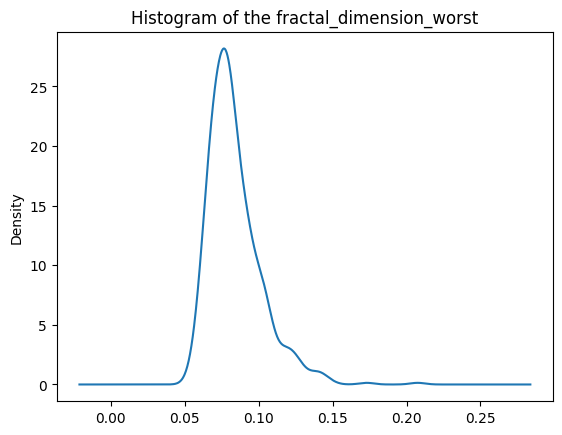

In [145]:
for col in X_train_cols:
  print(col,"Skewnness",df[col].skew())
  df[col].plot(kind='kde')
  plt.title(f"Histogram of the {col}")
  plt.show()

In [146]:
X_train_tensor=torch.from_numpy(X_train.values).float()
X_test_tensor=torch.from_numpy(X_test.values).float()
y_train_tensor=torch.from_numpy(Y_train_encoded).float()
y_test_tensor=torch.from_numpy(Y_test_encoded).float()

In [147]:
print(f"X_train_tensor dtype: {X_train_tensor.dtype}")
print(f"X_test_tensor dtype: {X_test_tensor.dtype}")
print(f"y_train_tensor dtype: {y_train_tensor.dtype}")
print(f"y_test_tensor dtype: {y_test_tensor.dtype}")

# Initialize model to check its parameter dtypes
model_check = MYSimpleNN(X_train_tensor.shape[1])
print(f"Model linear layer weight dtype: {model_check.linear.weight.dtype}")
print(f"Model linear layer bias dtype: {model_check.linear.bias.dtype}")

X_train_tensor dtype: torch.float32
X_test_tensor dtype: torch.float32
y_train_tensor dtype: torch.float32
y_test_tensor dtype: torch.float32
Model linear layer weight dtype: torch.float32
Model linear layer bias dtype: torch.float32


In [148]:
import torch.nn as nn

In [171]:
class MYSimpleNN(nn.Module):
  def __init__(self,input_size):
    super().__init__()
    self.linear=nn.Linear(input_size,10)
    self.relu=nn.ReLU()
    self.linear2=nn.Linear(10,5)
    self.relu2=nn.ReLU()
    self.linear3=nn.Linear(5,1)
    self.sigmoid=nn.Sigmoid()
  def forward(self,features):
    x=self.linear(features)
    x=self.sigmoid(x)
    x=self.linear2(x)
    x=self.relu2(x)
    x=self.linear3(x)
    x=self.sigmoid(x)
    return x

In [172]:
learning_rate=0.1
epoches=25

In [173]:
loss_function=nn.BCELoss()

In [174]:
#Create the Model
model=MYSimpleNN(X_train_tensor.shape[1])
#intialize the optimizer
optimizer=torch.optim.SGD(model.parameters(),lr=learning_rate)
#Define LOOP
for epoch in range(epoches):
  #Forward Pass
  y_pred=model(X_train_tensor)
  #Compute Loss
  loss=loss_function(y_pred,y_train_tensor.view(-1,1))
  #clear gradients
  optimizer.zero_grad()
  #Backward pass
  loss.backward()
  #parameters update
  optimizer.step()
  print(f"Epoch:{epoch},loss:{loss.item()}")


Epoch:0,loss:0.7162957191467285
Epoch:1,loss:0.6983749270439148
Epoch:2,loss:0.7036519646644592
Epoch:3,loss:0.6949296593666077
Epoch:4,loss:0.6911241412162781
Epoch:5,loss:0.6884534955024719
Epoch:6,loss:0.6859164834022522
Epoch:7,loss:0.6833465695381165
Epoch:8,loss:0.6809815764427185
Epoch:9,loss:0.6787033081054688
Epoch:10,loss:0.6767033338546753
Epoch:11,loss:0.6748364567756653
Epoch:12,loss:0.6730798482894897
Epoch:13,loss:0.6714685559272766
Epoch:14,loss:0.6695882678031921
Epoch:15,loss:0.6679304242134094
Epoch:16,loss:0.6613759994506836
Epoch:17,loss:0.6727457642555237
Epoch:18,loss:0.6711516976356506
Epoch:19,loss:0.6697277426719666
Epoch:20,loss:0.6684161424636841
Epoch:21,loss:0.6668376326560974
Epoch:22,loss:0.6547198295593262
Epoch:23,loss:0.6616977453231812
Epoch:24,loss:0.660187840461731


In [175]:
#model evaluation
with torch.no_grad():
  y_pred=model.forward(X_test_tensor)
  y_pred_class=(y_pred>0.5).float()
  print(y_pred_class)
  accuracy=(y_pred_class==y_test_tensor).float().mean()
  print(f"Accuracy:{accuracy}")

tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
      

In [155]:
y_pred_class

tensor([[1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
      